# Amazon Prime Exploratory Data Analysis Project

[github_repo](https://github.com/swapitsneil/Amazon-Prime-TV-Shows-and-Movies)

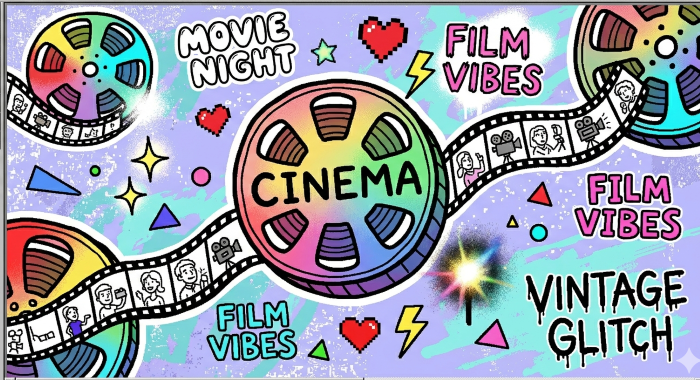

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [221]:
title = pd.read_csv('titles.csv')
credit = pd.read_csv('credits.csv')

In [222]:
title.sample(5)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
5553,tm200517,Babysitter,MOVIE,A dysfunctional L.A. family hires a mysterious...,2015,NaN,80,['comedy'],['FR'],NaN,tt3446062,5.7,138.0,2.148,6.4
4959,tm170031,Avalanche Sharks,MOVIE,"A snow avalanche awakens humungous, prehistori...",2014,NaN,82,"['horror', 'scifi', 'thriller', 'action', 'com...",['CA'],NaN,tt2622826,2.3,2272.0,8.875,3.4
1731,tm93565,Wetbacks,MOVIE,Former Coastguardsmen Jim Benson is about to l...,1956,NaN,89,"['crime', 'action', 'drama']",['US'],NaN,tt0049946,5.2,85.0,1.301,5.7
2117,tm205462,Baby Cat,MOVIE,The life of a Parisian photo model turns into ...,1983,R,80,"['comedy', 'european']",['FR'],NaN,tt0085206,3.3,124.0,1.054,3.0
8922,tm927961,Touch,MOVIE,"Fei Fei, a married Caucasian western woman mee...",2020,NaN,97,"['thriller', 'romance']",[],NaN,tt12483492,5.2,65.0,0.671,5.0


In [223]:
credit.sample(5)

,person_id,id,name,character,role
20894,2188963,tm97803,Alvin Attles,Himself,ACTOR
83200,10294,tm310461,James Cosmo,Roger Daniels,ACTOR
120494,470170,tm1032930,Erin Day,Baker,ACTOR
5863,37831,tm59437,Ray Teal,Ned Moore,ACTOR
111542,139005,tm814205,Mime Gopi,Raghul's Father,ACTOR


In [224]:
title.shape

(9871, 15)

In [225]:
credit.shape

(124235, 5)

In [226]:
title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [227]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [228]:
title.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [229]:
# checking missing values

round((title.isnull().sum()/len(title))*100,2)

,0
id,0.00
title,0.00
type,0.00
description,1.21
release_year,0.00
age_certification,65.72
runtime,0.00
genres,0.00
production_countries,0.00
seasons,86.25


In [230]:
round((credit.isnull().sum()/len(title))*100,2)

,0
person_id,0.0
id,0.0
name,0.0
character,165.0
role,0.0


handling missing values

seasons is having approx 86% missing values as a data analyst i cant delete

In [231]:
# filling categorical missing values

title['age_certification'] = title['age_certification'].fillna('Unknown')
title['description'] = title['description'].fillna('No Description')

In [232]:
# filling numerical missing values

title['imdb_score'] = title['imdb_score'].fillna(title['imdb_score'].median())
title['tmdb_score'] = title['tmdb_score'].fillna(title['tmdb_score'].median())
title['imdb_votes'] = title['imdb_votes'].fillna(title['imdb_votes'].median())
title['tmdb_popularity'] = title['tmdb_popularity'].fillna(title['tmdb_popularity'].median())

In [233]:
# duplicate handling

print(title.duplicated().sum())

title.drop_duplicates(inplace=True)

3


Merging Datasets

In [234]:
df = pd.merge(title, credit, on='id', how='inner')

In [235]:
df.sample(5)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
115622,tm895956,Code of Thieves,MOVIE,Making the mistake of robbing a powerful drug ...,2020,Unknown,92,['action'],[],NaN,NaN,6.1,462.5,1.905,3.0,1759164,Tory Monay,Rachel,ACTOR
1828,tm62593,Nothing Sacred,MOVIE,When a small-town girl is diagnosed with a rar...,1937,Unknown,77,"['romance', 'drama', 'fantasy', 'comedy']",['US'],NaN,tt0029322,6.9,6570.0,4.764,6.3,14710,John Qualen,Fireman (uncredited),ACTOR
105684,tm908277,Target Number One,MOVIE,"Ex heroin junkie, Daniel Léger, gets involved ...",2020,R,135,"['thriller', 'crime']",['CA'],NaN,tt4719542,6.1,4610.0,9.440,6.4,1321734,Kenneth Won,Lawyer Ensu,ACTOR
36906,tm123365,Brass,MOVIE,The Chief of Detectives of the New York Police...,1985,PG,100,"['crime', 'drama']",['US'],NaN,tt0088845,6.0,100.0,0.675,6.0,312055,Robert Brown,Chief Shannon,ACTOR
51900,ts32321,Holby Blue,SHOW,The police force at Holby South is tasked with...,2007,Unknown,52,"['drama', 'crime']",['GB'],2.0,tt0849988,6.5,333.0,3.971,6.5,330512,Elaine Glover,Rookie Lucy Slater,ACTOR


In [236]:
df.shape

(124235, 19)

In [237]:
df['genres'].unique()

array(["['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']",
       "['action', 'drama', 'war', 'western', 'comedy', 'european']",
       "['romance', 'war', 'drama']", ...,
       "['drama', 'romance', 'comedy', 'history']",
       "['thriller', 'western', 'comedy']",
       "['comedy', 'action', 'family']"], dtype=object)

In [238]:
df['production_countries'].unique()

array(["['US']", "['GB']", "['MX', 'US']", "['GB', 'CA']", "['DE', 'US']",
       "['SU']", "['IN']", "['CA', 'US']", "['MX']", "['XX']", '[]',
       "['US', 'IT']", "['JP']", "['IT', 'FR']", "['HK']",
       "['FR', 'DE', 'IT']", "['ES', 'IT']", "['GB', 'US']",
       "['IL', 'US']", "['US', 'FR', 'IT']", "['IT']",
       "['IT', 'GB', 'US']", "['GB', 'US', 'IT', 'MX', 'ES']",
       "['AU', 'US']", "['CH', 'GB']", "['CA', 'FR']", "['US', 'IE']",
       "['GB', 'IT']", "['IT', 'US']", "['FR']", "['GR', 'US']", "['DE']",
       "['HK', 'US', 'CN']", "['US', 'ES']", "['PH', 'US']",
       "['NL', 'US']", "['FR', 'US']", "['IT', 'YU']",
       "['FR', 'DE', 'CH', 'CI']", "['PR', 'US']", "['US', 'PH']",
       "['YU', 'US']", "['IT', 'MX']", "['IT', 'ES', 'DE', 'LI']",
       "['US', 'CA']", "['US', 'GB']", "['US', 'DE']",
       "['US', 'IT', 'FR']", "['CA']", "['FR', 'GB']", "['JP', 'KR']",
       "['GR']", "['ES']", "['US', 'JP']", "['SU', 'US']", "['FR', 'DE']",
       "['FR', 'IT']"

UNIVARIATE ANALYSIS

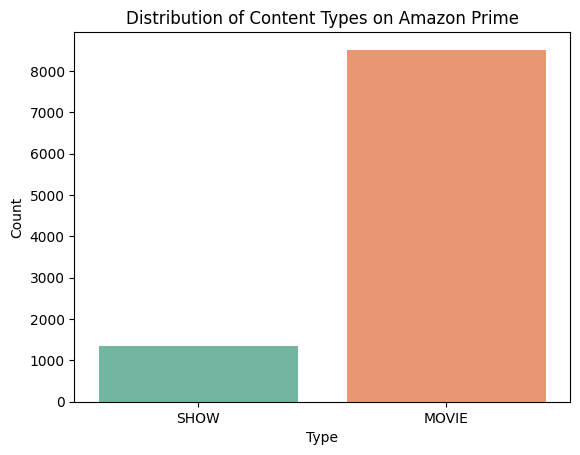

In [239]:
# chart for movies vs shows

sns.countplot(data=title, x='type', hue='type', palette='Set2',legend=False)

plt.title('Distribution of Content Types on Amazon Prime')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

Movies represent the majority of the catalog, indicating a stronger investment in standalone content than episodic programming

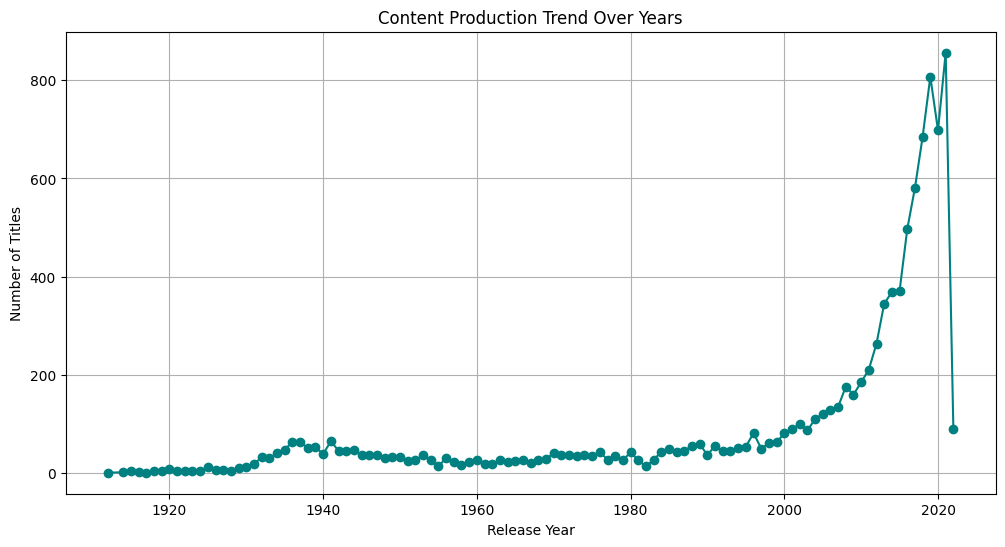

In [240]:
# release year trend

yearly = title['release_year'].value_counts().sort_index()
yearly.plot(kind='line', marker='o', figsize=(12,6), color='teal')
plt.title('Content Production Trend Over Years')
plt.xlabel('Release Year'); plt.ylabel('Number of Titles')
plt.grid(True)

Content production accelerated significantly after 2010, reflecting rapid expansion of Amazon Prime's content library

In [241]:
stats = {
    'mean':'mean',
    'median':'median',
    'max':'max',
    'min':'min'
}

df['imdb_score'].agg(stats)

,imdb_score
mean,5.974568
median,6.100000
max,9.900000
min,1.100000


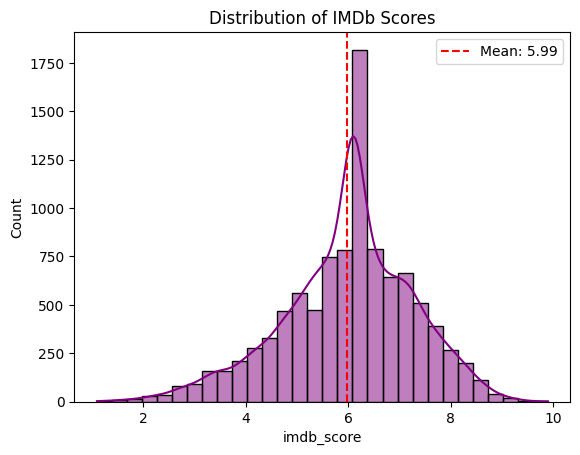

In [242]:
# imdb score distribution

sns.histplot(title['imdb_score'], kde=True, bins=30, color='purple')
plt.title('Distribution of IMDb Scores')
plt.axvline(title['imdb_score'].mean(), color='red', linestyle='--', label=f'Mean: {title["imdb_score"].mean():.2f}')
plt.legend()

most content falls within average imdb ratings

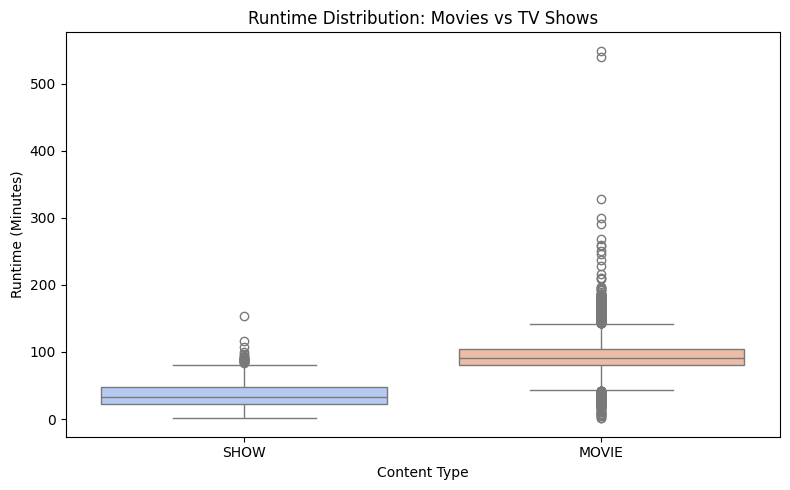

In [243]:
# analyzing runtime distribution

plt.figure(figsize=(8,5))

sns.boxplot(data=title, x='type', y='runtime', hue='type', palette='coolwarm', legend=False)

plt.title('Runtime Distribution: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Runtime (Minutes)')

plt.tight_layout()
plt.show()

most content is concentrated around standard movie duration while a few titles contain extremely high runtime creating a right skewed distribution

In [244]:
df['age_certification'].value_counts()

,count
age_certification,
Unknown,67528
R,25931
PG-13,12492
PG,9617
G,3839
TV-MA,1732
TV-14,1583
TV-PG,501
TV-Y7,356


In [245]:
# age certification categories

age_map = {

    'G':'Kids',
    'TV-Y':'Kids',
    'TV-Y7':'Kids',
    'PG':'Family',
    'TV-PG':'Family',
    'PG-13':'Teens',
    'TV-14':'Teens',
    'R':'Adults',
    'TV-MA':'Adults',
    'NC-17':'Adults',
    'Unknown':'Unknown'

}

df['age_certification'] = df['age_certification'].map(age_map)

Text(0.5, 1.0, 'Content by Age Certification')

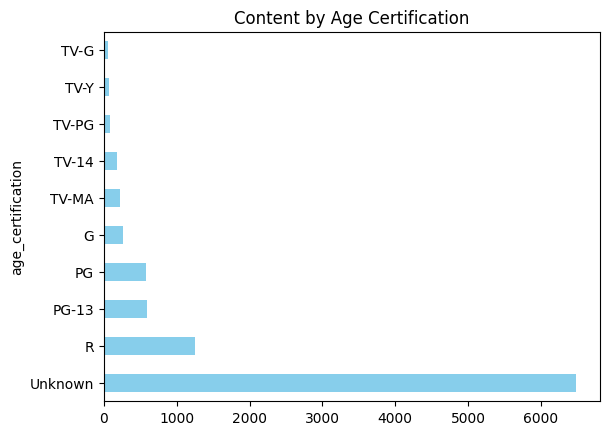

In [246]:
title['age_certification'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Content by Age Certification')

amazon prime content is heavily concentrated toward adult and teen audiences while kids focused content forms a smaller portion of the platform

Text(0.5, 1.0, 'Top 10 Genres on Amazon Prime')

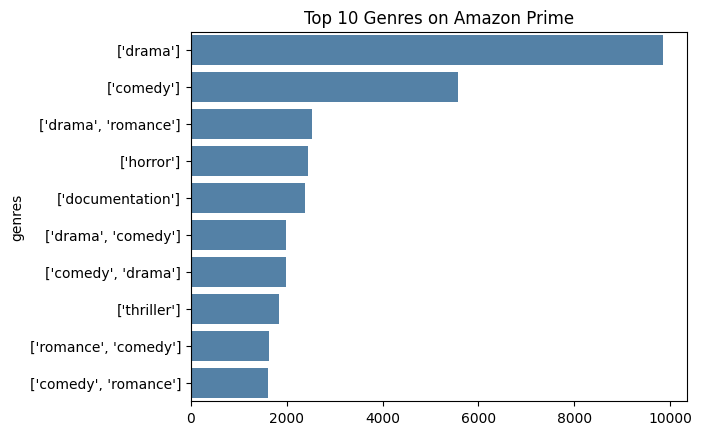

In [268]:
# top genres

top_genres = df['genres'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, color='steelblue')
plt.title('Top 10 Genres on Amazon Prime')

drama comedy and thriller dominate the platform

Text(0.5, 1.0, 'Top Production Countries')

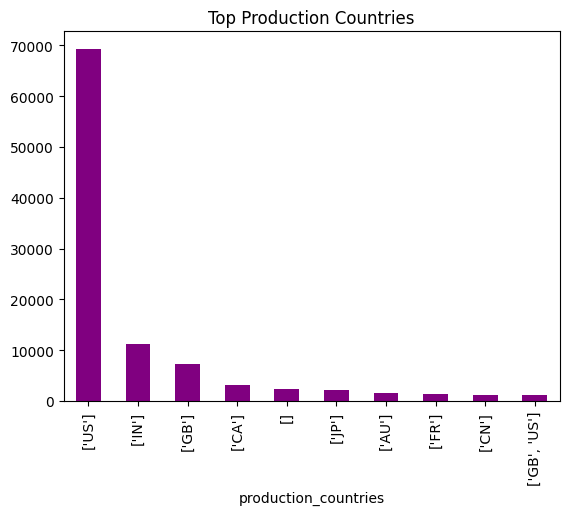

In [248]:
# top production countries

top_countries = df['production_countries'].value_counts().head(10)
top_countries.plot(kind='bar', color='purple')
plt.title('Top Production Countries')

The United States contributes the largest share of titles

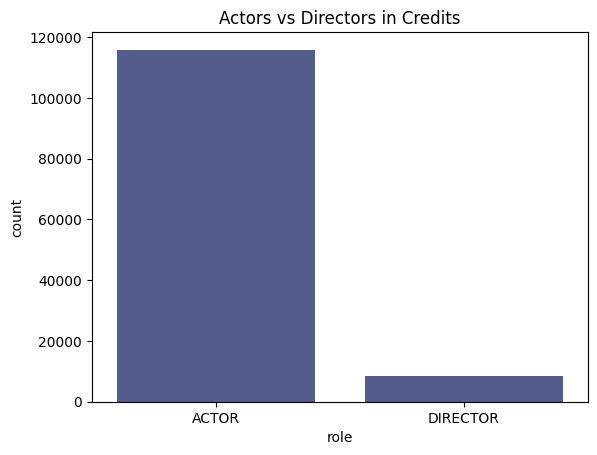

In [249]:
# role distribution

sns.countplot(data=df, x='role', color='#4B5694')

plt.title('Actors vs Directors in Credits')
plt.show()

Actor records greatly outnumber director records because each title typically contains multiple cast members but only a few directors

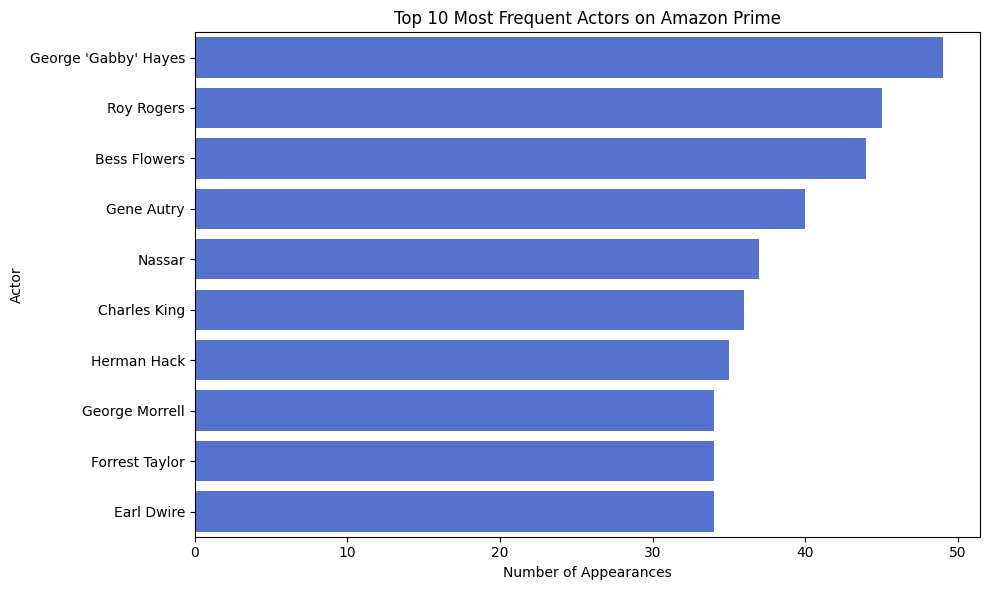

In [250]:
# top actors

actors = df[df['role']=='ACTOR']
top_actors = actors['name'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_actors.values, y=top_actors.index, color='royalblue')

plt.title('Top 10 Most Frequent Actors on Amazon Prime')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')

plt.tight_layout()
plt.show()

A small group of actors appears repeatedly across the platform, indicating Amazon Prime relies on established talent to strengthen its content catalog

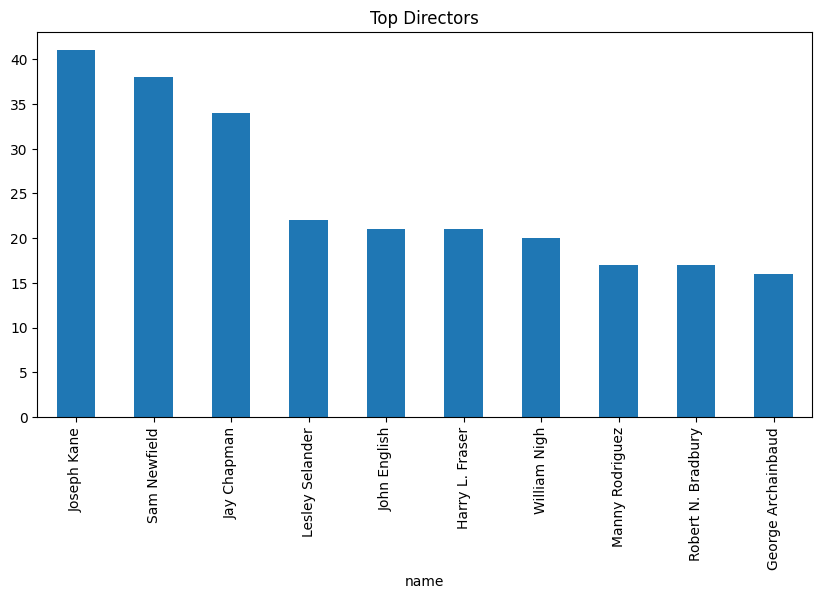

In [251]:
# top directors

directors = df[df['role']=='DIRECTOR']

directors['name'].value_counts().head(10).plot(kind='bar', figsize=(10,5))

plt.title('Top Directors')

plt.show()

A few directors contribute to a large number of titles, suggesting repeated collaboration with experienced content creators.

BIVARIATE ANALYSIS

Text(0.5, 1.0, 'IMDb vs TMDB Score Relationship')

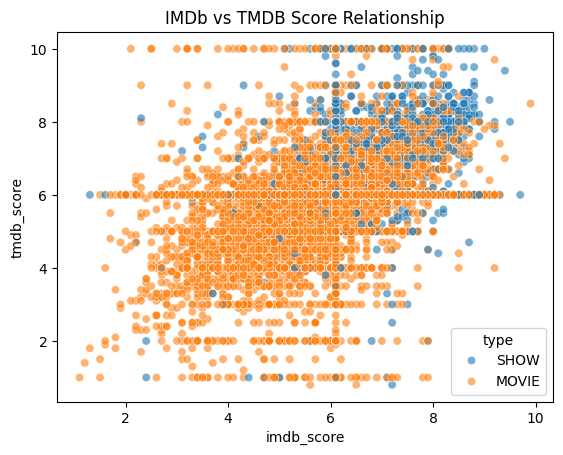

In [252]:
# imdb vs tmdb score

sns.scatterplot(data=title, x='imdb_score', y='tmdb_score', alpha=0.6, hue='type')
plt.title('IMDb vs TMDB Score Relationship')

titles with higher imdb ratings generally receive higher tmdb ratings showing consistent audience perception across different rating platforms                                 Strong positive correlation

Text(0.5, 1.0, 'Feature Correlation Heatmap')

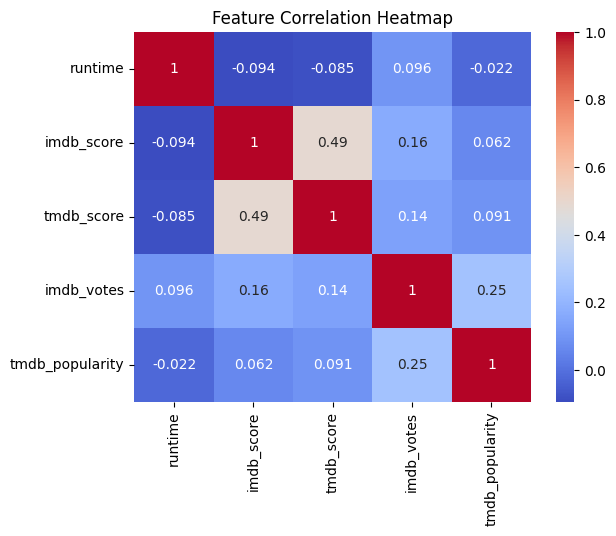

In [253]:
# correlation heatmap

numeric = title[['runtime', 'imdb_score', 'tmdb_score', 'imdb_votes', 'tmdb_popularity']]
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

imdb and tmdb scores show moderate positive correlation indicating similar audience rating patterns across both platforms

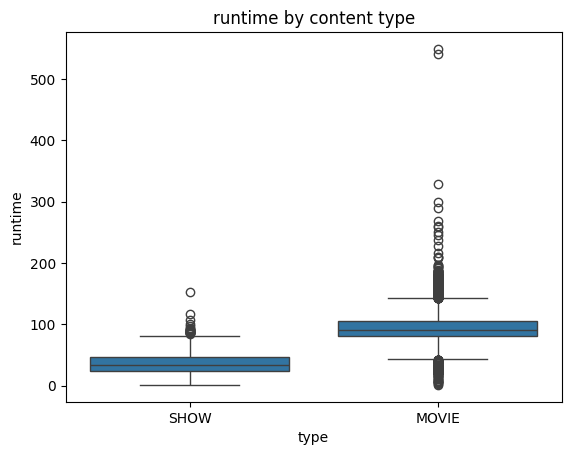

In [254]:
# runtime by type

sns.boxplot(x='type', y='runtime', data=title)
plt.title('runtime by content type')

plt.show()

movies have wider runtime variation than shows

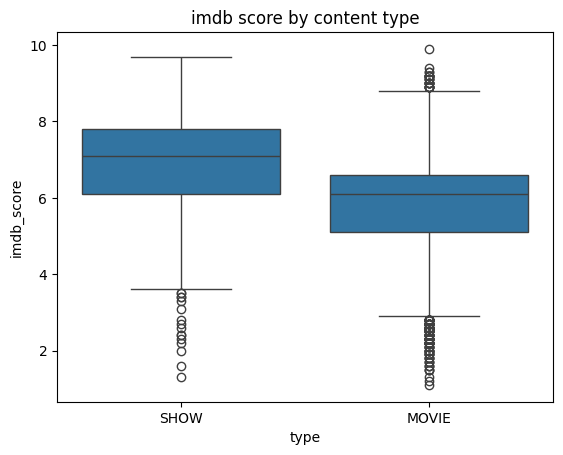

In [269]:
# imdb score by type

sns.boxplot(x='type',y='imdb_score', data=title)
plt.title('imdb score by content type')

plt.show()

tv shows slightly outperform movies in audience ratings

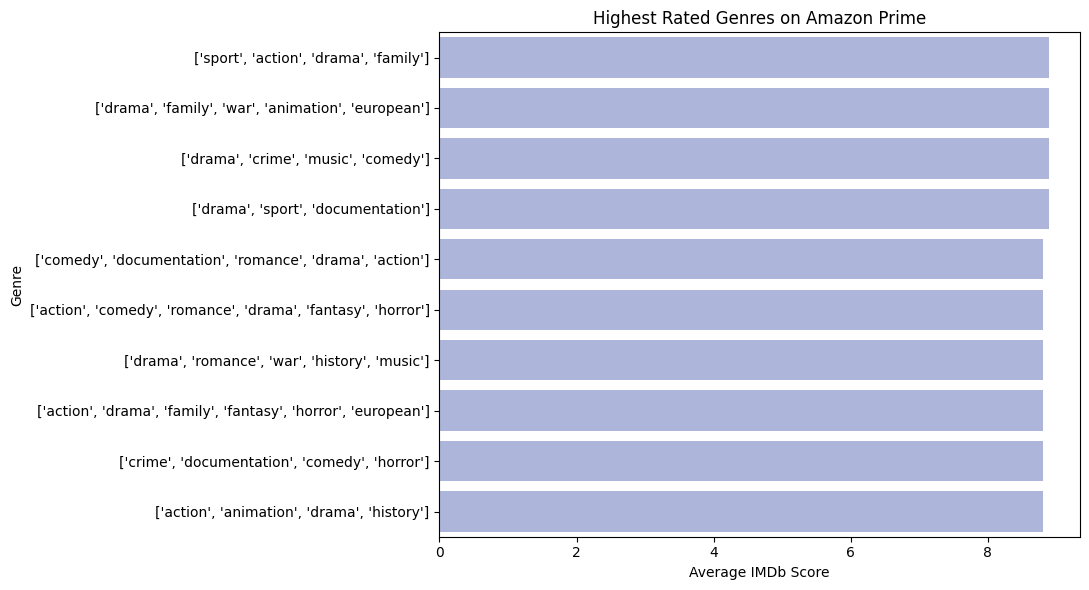

In [256]:
# Genre Performance (Avg IMDb Score)

genre_scores = (df.groupby('genres')['imdb_score'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(11,6))

sns.barplot(x=genre_scores.values, y=genre_scores.index, color='#A6B1E1')

plt.title('Highest Rated Genres on Amazon Prime')
plt.xlabel('Average IMDb Score')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

Certain genre combinations consistently achieve higher IMDb ratings, indicating stronger audience appreciation for those content categories

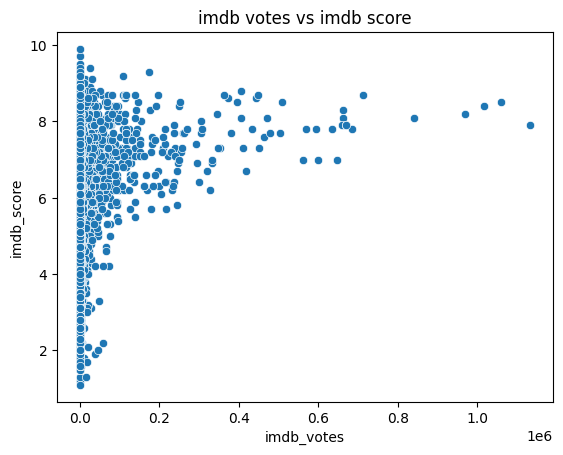

In [257]:
# imdb votes vs imdb score

sns.scatterplot(x='imdb_votes',y='imdb_score',data=title)
plt.title('imdb votes vs imdb score')

plt.show()

high imdb votes do not always guarantee high imdb scores showing that popularity and audience satisfaction are not always directly related

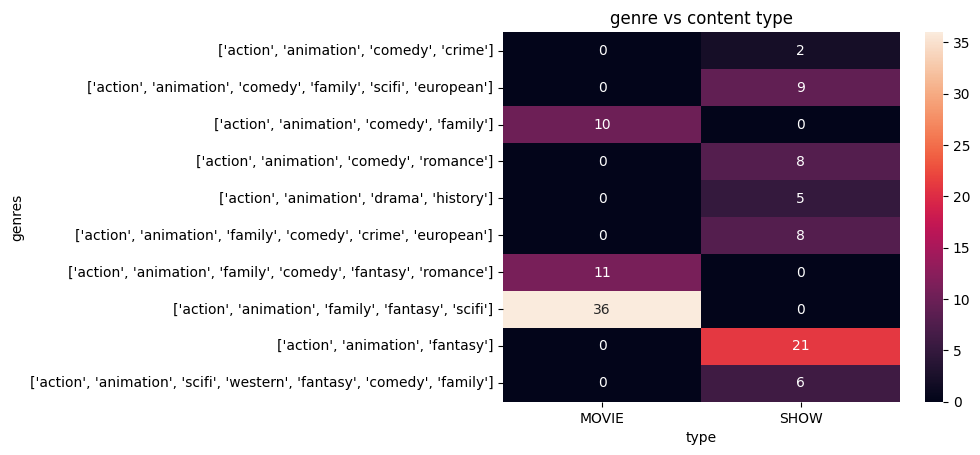

In [258]:
# genre vs type

genre_type = pd.crosstab(df['genres'],df['type']).head(10)
sns.heatmap(genre_type, annot=True)
plt.title('genre vs content type')

plt.show()

certain genre combinations are more dominant in movies while others are more frequently produced as shows indicating different storytelling preferences across content types

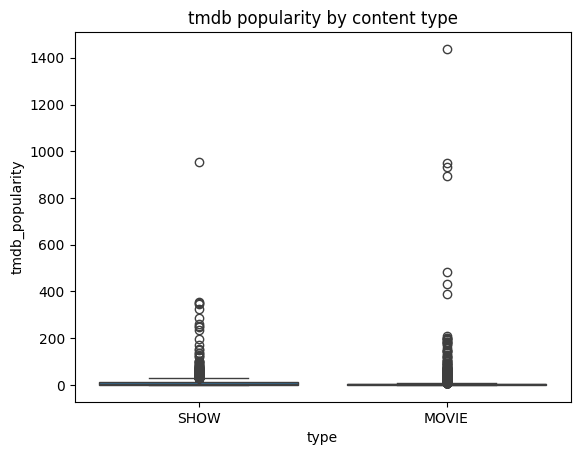

In [259]:
# tmdb popularity by type

sns.boxplot(x='type', y='tmdb_popularity', data=title)
plt.title('tmdb popularity by content type')

plt.show()

movies generally attract wider popularity reach than shows

MULTIVARIATE ANALYSIS

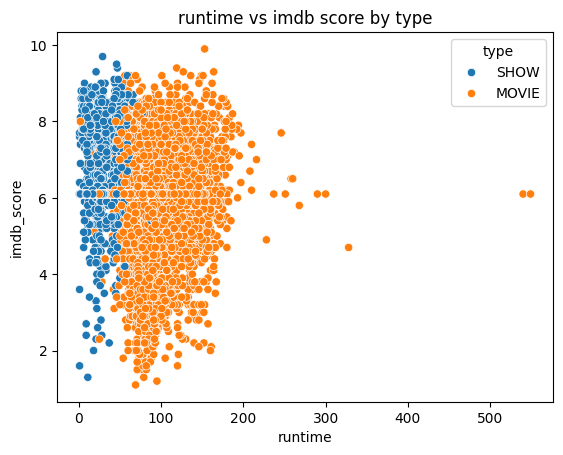

In [260]:
# runtime vs imdb score by type

sns.scatterplot(x='runtime', y='imdb_score', hue='type', data=title)
plt.title('runtime vs imdb score by type')

plt.show()

longer runtime does not necessarily improve ratings

In [261]:
# content growth over years

yearly_content = df.groupby(['release_year','type']).size().reset_index(name='count')

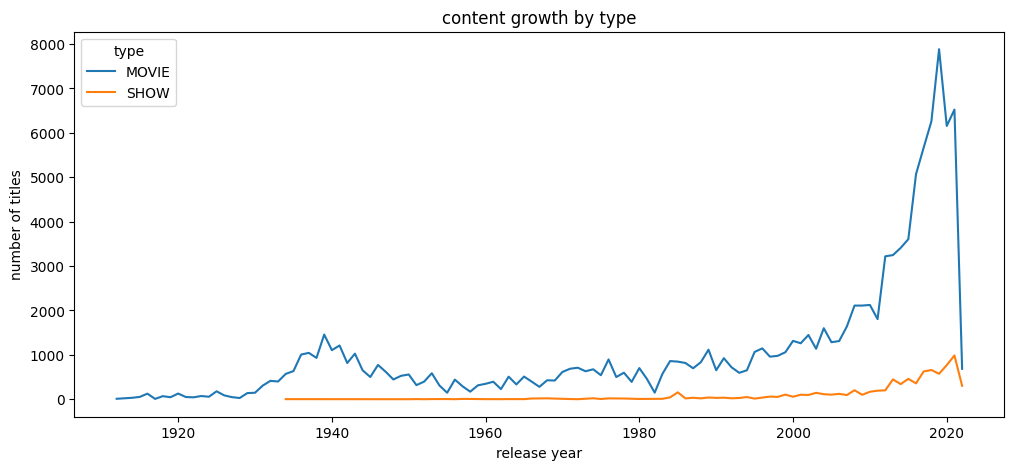

In [262]:
plt.figure(figsize=(12,5))

sns.lineplot(x='release_year', y='count', hue='type', data=yearly_content)

plt.title('content growth by type')
plt.xlabel('release year')
plt.ylabel('number of titles')

plt.show()

movie production increased sharply after 2010 while show content experienced gradual growth over time

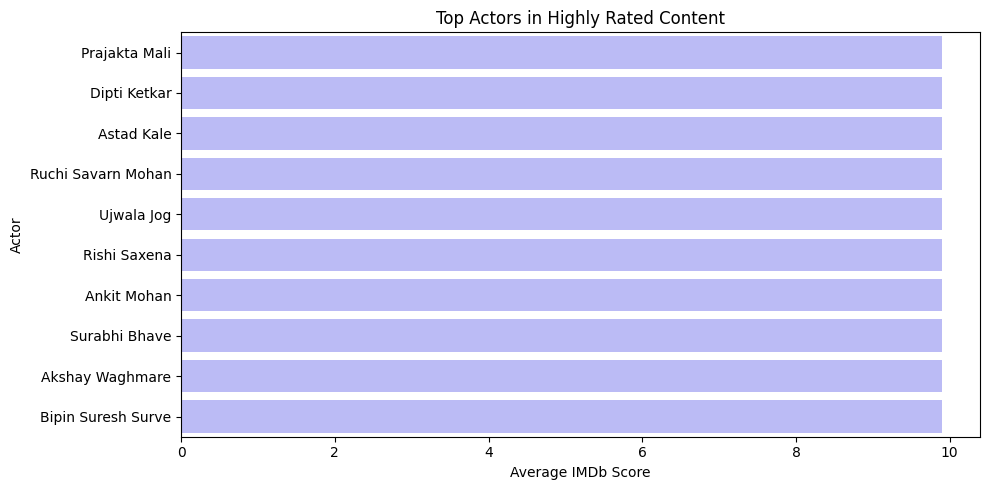

In [270]:
# top actors in highly rated content

top_actor_scores = (actors.groupby('name')['imdb_score'].mean().sort_values(ascending=False).head(10).sort_values())

plt.figure(figsize=(10,5))

sns.barplot(x=top_actor_scores.values, y=top_actor_scores.index, color='#B1B2FF')

plt.title('Top Actors in Highly Rated Content')
plt.xlabel('Average IMDb Score')
plt.ylabel('Actor')

plt.tight_layout()
plt.show()

certain actors consistently appear in highly rated content

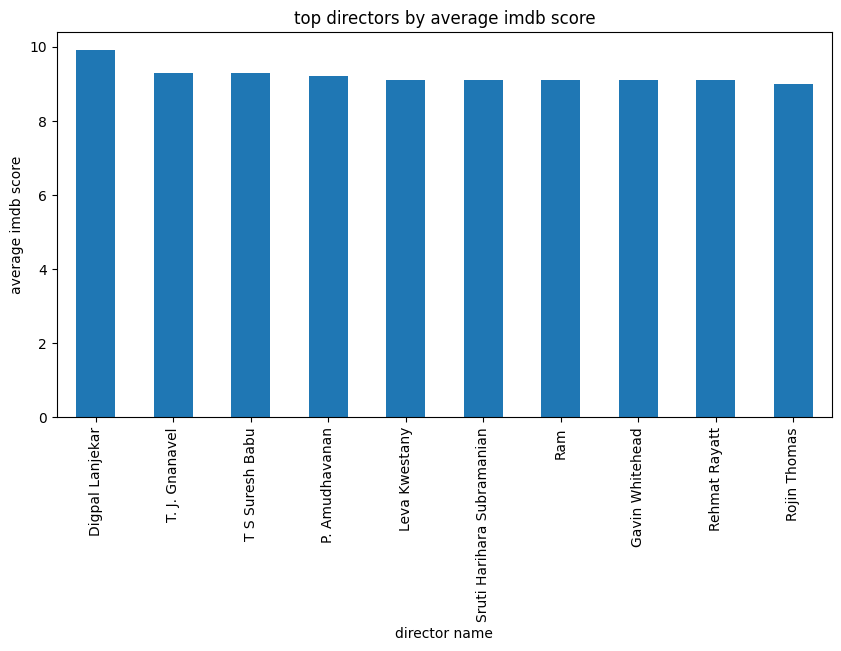

In [271]:
# top directors by average imdb score

top_director_scores = directors.groupby('name')['imdb_score'].mean().sort_values(ascending=False).head(10)
top_director_scores.plot(kind='bar', figsize=(10,5))
plt.title('top directors by average imdb score')
plt.xlabel('director name')
plt.ylabel('average imdb score')

plt.show()

Some directors consistently deliver highly rated content, making them valuable contributors to overall platform quality

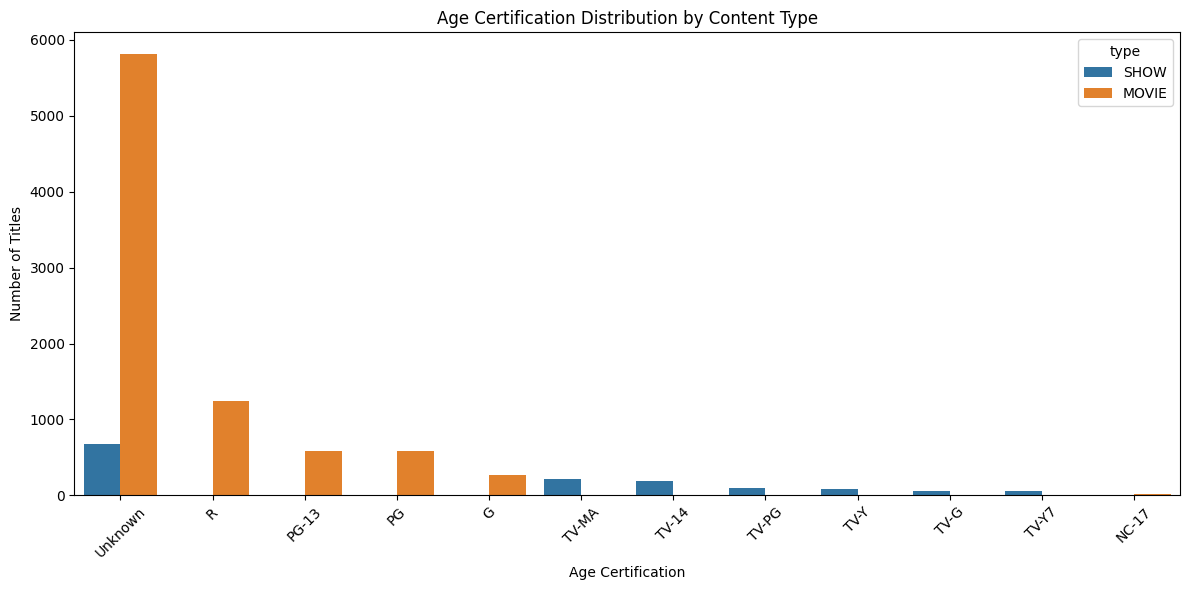

type               MOVIE  SHOW
age_certification             
G                    269     0
NC-17                 13     0
PG                   582     0
PG-13                588     0
R                   1249     0
TV-14                  0   188
TV-G                   0    57
TV-MA                  0   217
TV-PG                  0    91
TV-Y                   0    78
TV-Y7                  0    52
Unknown             5810   674


In [265]:
# Age Certification vs Content Type

title["age_certification"] = (title["age_certification"].fillna("Unknown"))

plt.figure(figsize=(12,6))

sns.countplot(data=title,x="age_certification",hue="type", order=title["age_certification"].value_counts().index)

plt.title("Age Certification Distribution by Content Type")

plt.xlabel("Age Certification")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(pd.crosstab(title["age_certification"],title["type"]))

Teen and adult certifications dominate both movies and shows, indicating the platform primarily targets mature audiences

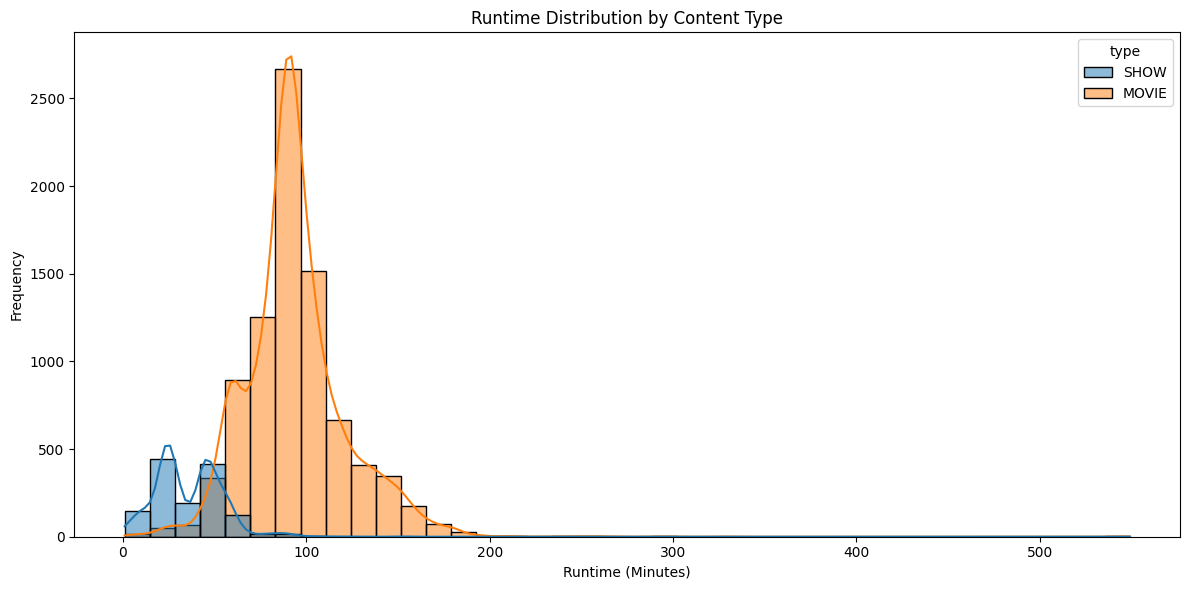

        count       mean        std  min   25%   50%    75%    max
type                                                              
MOVIE  8511.0  93.979556  28.053207  1.0  80.0  91.0  105.0  549.0
SHOW   1357.0  35.801032  17.702438  1.0  23.0  33.0   47.0  153.0


In [266]:
# Runtime Distribution by Content Type

plt.figure(figsize=(12,6))

sns.histplot(data=title, x="runtime", hue="type", kde=True,bins=40)

plt.title("Runtime Distribution by Content Type")

plt.xlabel("Runtime (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(title.groupby("type")["runtime"].describe())

Movies are concentrated around longer runtimes, while TV shows generally have shorter durations suited for episodic viewing

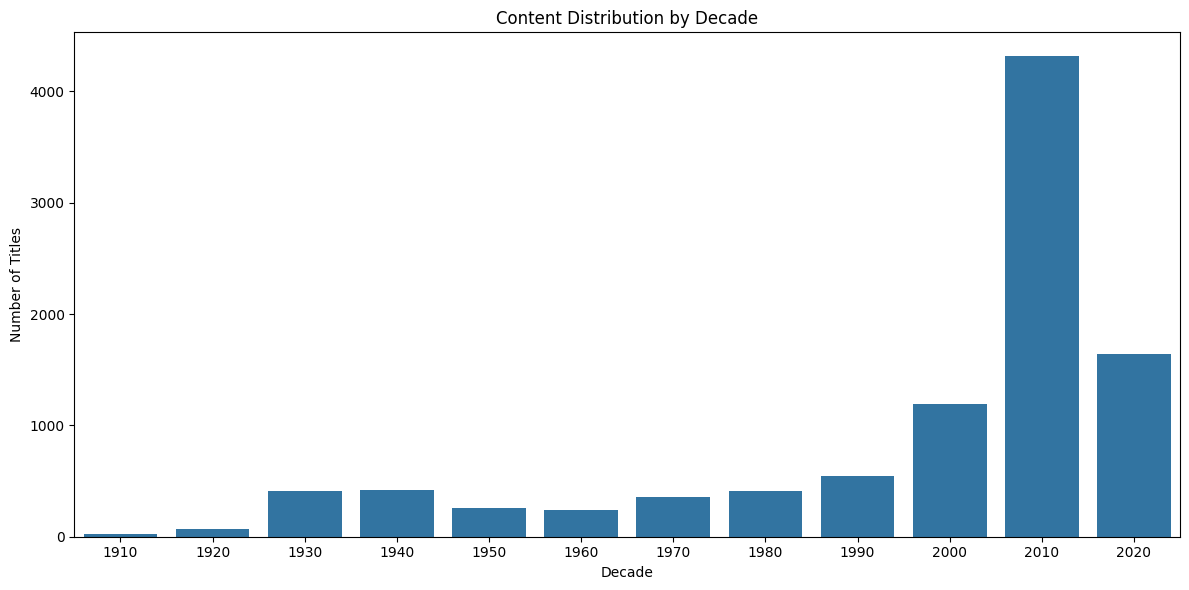

decade
1910      20
1920      65
1930     414
1940     420
1950     254
1960     239
1970     355
1980     408
1990     546
2000    1189
2010    4315
2020    1643
Name: count, dtype: int64


In [267]:
# Content Distribution by Decade

title["decade"] = (title["release_year"] // 10) * 10

decade_counts = (title["decade"].value_counts().sort_index())

plt.figure(figsize=(12,6))

sns.barplot(x=decade_counts.index, y=decade_counts.values)

plt.title("Content Distribution by Decade")

plt.xlabel("Decade")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

print(decade_counts)

Most content originates from recent decades, reflecting Amazon Prime's focus on modern and contemporary entertainment

# FINAL CONCLUSION

FINAL CONCLUSION

• Amazon Prime's catalog is heavily dominated by movies, indicating a stronger emphasis on standalone entertainment content.

• Content production has grown substantially since 2010, reflecting the platform's rapid expansion and increasing investment in content acquisition.

• Drama, Comedy, and Thriller emerge as the most prominent genres, suggesting strong audience demand for these categories.

• The United States remains the leading content-producing country, contributing a significant portion of the platform's library.

• IMDb and TMDB ratings show a positive relationship, indicating consistent audience perception across rating platforms.

• TV shows generally achieve slightly higher audience ratings than movies, while movies attract broader popularity and engagement.

• Runtime has limited influence on content quality, as longer titles do not necessarily receive better ratings.

• A small group of actors and directors appears repeatedly across highly rated content, highlighting the importance of experienced talent within the platform.

Overall, Amazon Prime's content strategy appears focused on expanding a movie-heavy catalog, leveraging established talent, investing in modern content, and targeting primarily teen and adult audiences.

[GITHUB-REPO](https://github.com/swapitsneil/Amazon-Prime-TV-Shows-and-Movies)

[PROJECT-EXPLANATION](https://youtu.be/nQhV__Wf9Hk)